## Sesión de IA tradicional
### Entrenando un modelo predictivo de la Copa del Mundo 2026

En este notebook verás, paso a paso:
- Preparación de los datos
- Cálculo de ELO -> fuerza de los equipos
- Entrenamiento de modelos -> resultado + goles
- Evaluación usando la Copa del Mundo 2022
- Generación de predicciones a partir de dos equipos

Todo organizado de forma simple para ejecutar celda por celda.

---

### Accediendo a los datos
Datos cargados en la sesión anterior en la capa Bronze, que serían los datos raw (sin pre-procesamiento).

In [53]:
bronze_df = spark.table("deepdivecatalog_bronze.admin.bronze_wc_matches")
display(bronze_df.limit(5))

### Cargar y limpiar datos
Realizando algunas operaciones básicas de limpieza en los datos para guardar en la capa Plata.

In [54]:
from pyspark.sql.functions import col, to_date, when

silver_df = (
    bronze_df
    
    # padronizar nomes de colunas
    .toDF(*[c.lower().strip() for c in bronze_df.columns])
    
    # substituir vazio por null
    .select([
        when(col(c) == "", None).otherwise(col(c)).alias(c)
        for c in bronze_df.columns
    ])
    
    # conversões básicas 
    .withColumn("match_date", to_date(col("match_date"), "M/d/yyyy"))
    
    # remover duplicados simples
    .dropDuplicates()
    
    # remover linhas inválidas essenciais
    .filter(col("home_team_name").isNotNull())
	.filter(col("away_team_name").isNotNull())
)

silver_df = silver_df \
    .withColumn("home_team_score", col("home_team_score").cast("int")) \
    .withColumn("away_team_score", col("away_team_score").cast("int")) \
    .filter(col("home_team_score").isNotNull()) \
    .filter(col("away_team_score").isNotNull())

In [55]:
silver_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("deepdivecatalog_prata.silver_wc_matches")

### Preparación para el modelo - Feature engineering
Esta etapa consiste en algunas manipulaciones de los datos para generar buenas variables para el modelo, llamamos a este proceso feature engineering.

#### Convirtiendo a pandas

In [56]:
df_pd = silver_df.orderBy("match_date").toPandas()

#### Creando la variable de ELO
El ELO es un sistema de puntuación usado para medir la fuerza de un equipo en base a sus resultados a lo largo del tiempo. La idea es simple:

- Los equipos comienzan con una puntuación inicial (1500)
- En cada partido, esa puntuación se ajusta
- Si un equipo gana, sube en el ranking
- Si pierde, baja
- Si empata, ambos se ajustan levemente

El ELO transforma el historial de partidos en una medida numérica de desempeño.

En vez de usar solo el marcador del partido actual, el modelo pasa a considerar:

- Historial acumulado
- Consistencia de los equipos
- Nivel de los rivales enfrentados

In [57]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating, expected, actual, k=30):
    return rating + k * (actual - expected)


def compute_elo(df, k=30):

    df = df.sort_values("match_date").copy()

    ratings = {}
    elo_home = []
    elo_away = []

    for _, row in df.iterrows():

        home = row["home_team_name"]
        away = row["away_team_name"]

        ratings.setdefault(home, 1500)
        ratings.setdefault(away, 1500)

        rating_home = ratings[home]
        rating_away = ratings[away]

        elo_home.append(rating_home)
        elo_away.append(rating_away)

        expected_home = expected_score(rating_home, rating_away)
        expected_away = expected_score(rating_away, rating_home)

        if row["home_team_win"] == 1:
            actual_home, actual_away = 1, 0
        elif row["away_team_win"] == 1:
            actual_home, actual_away = 0, 1
        else:
            actual_home = actual_away = 0.5

        ratings[home] = update_elo(rating_home, expected_home, actual_home, k)
        ratings[away] = update_elo(rating_away, expected_away, actual_away, k)

    df["elo_home"] = elo_home
    df["elo_away"] = elo_away
    df["elo_diff"] = df["elo_home"] - df["elo_away"]

    return df, ratings


df, ratings = compute_elo(df_pd)

#### Creando métricas sobre los partidos para usar como variable en el modelo

In [58]:
import pandas as pd
def create_team_features(df):

    goals_for = pd.concat([
        df[["home_team_name", "home_team_score"]].rename(
            columns={"home_team_name": "Team", "home_team_score": "Goals_For"}
        ),
        df[["away_team_name", "away_team_score"]].rename(
            columns={"away_team_name": "Team", "away_team_score": "Goals_For"}
        )
    ])

    goals_against = pd.concat([
        df[["home_team_name", "away_team_score"]].rename(
            columns={"home_team_name": "Team", "away_team_score": "Goals_Against"}
        ),
        df[["away_team_name", "home_team_score"]].rename(
            columns={"away_team_name": "Team", "home_team_score": "Goals_Against"}
        )
    ])

    wins = pd.concat([
        df[["home_team_name", "home_team_win"]].rename(
            columns={"home_team_name": "Team", "home_team_win": "Win"}
        ),
        df[["away_team_name", "away_team_win"]].rename(
            columns={"away_team_name": "Team", "away_team_win": "Win"}
        )
    ])

    team_stats = goals_for.groupby("Team").mean()
    team_stats["avg_goals_against"] = goals_against.groupby("Team").mean()
    team_stats["win_rate"] = wins.groupby("Team").mean()

    return team_stats.fillna(0)


team_stats = create_team_features(df)

In [59]:
def add_match_features(df, team_stats):

    df = df.copy()

    df = df.merge(
        team_stats,
        left_on="home_team_name",
        right_index=True,
        how="left"
    ).rename(columns={
        "Goals_For": "teamA_avg_goals",
        "avg_goals_against": "teamA_avg_conceded",
        "win_rate": "teamA_win_rate"
    })

    df = df.merge(
        team_stats,
        left_on="away_team_name",
        right_index=True,
        how="left",
        suffixes=("", "_B")
    ).rename(columns={
        "Goals_For": "teamB_avg_goals",
        "avg_goals_against": "teamB_avg_conceded",
        "win_rate": "teamB_win_rate"
    })

    df["goals_diff"] = df["teamA_avg_goals"] - df["teamB_avg_goals"]
    df["defense_diff"] = df["teamA_avg_conceded"] - df["teamB_avg_conceded"]
    df["win_rate_diff"] = df["teamA_win_rate"] - df["teamB_win_rate"]

    return df


df = add_match_features(df, team_stats)

#### Preparación del dataset

In [60]:
def prepare_training_data(df: pd.DataFrame):

    features = [
        "elo_diff",
        "goals_diff",
        "defense_diff",
        "win_rate_diff"
    ]

    X = df[features]

    # Cria labels de derrota-> 0, empate -> 1, vitoria -> 2
    df["match_result"] = (
        df["home_team_win"] * 1 +
        df["away_team_win"] * 2
    )

    df["match_result"] = pd.to_numeric(df["match_result"], errors="coerce")
    df = df.dropna(subset=["match_result"])
    df["match_result"] = df["match_result"].astype(int)

    y_result = df["match_result"]
    y_home_goals = df["home_team_score"]
    y_away_goals = df["away_team_score"]

    return X, y_result, y_home_goals, y_away_goals

X, y_result, y_home, y_away = prepare_training_data(df)

#### Entrenando el modelo
Para el entrenamiento vamos a usar una técnica de `split` de los datos. Normalmente la proporción es de `70/30`, 30% de prueba y 70% de entrenamiento. Pero como los datos son pequeños, queremos darle más datos al entrenamiento para que el modelo tenga más muestra de datos, entonces vamos a usar la proporción `80/20`.

In [13]:
!pip install scikit-learn

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y_result, test_size=0.2, random_state=42
)

models = {}

# Modelo 1 - Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

models["rf"] = rf_model

# Modelo 2 - Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

models["logistic"] = log_model

#### Evaluación del modelo con el 20% de los datos ocultados anteriormente

In [62]:
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")

rf: 0.5596
logistic: 0.6062


#### Modelo predictivo de goles

In [63]:
home_goals_model = RandomForestRegressor()
home_goals_model.fit(X, y_home)

away_goals_model = RandomForestRegressor()
away_goals_model.fit(X, y_away)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Probando con datos de la Copa del Mundo 2022

In [64]:
df["year"] = pd.to_datetime(df["match_date"]).dt.year
df_2022 = df[df["year"] == 2022]

X_2022 = df_2022[["elo_diff", "goals_diff", "defense_diff", "win_rate_diff"]]
y_2022 = df_2022["match_result"]

model = models["rf"]

preds_2022 = model.predict(X_2022)

print("Accuracy Copa 2022:", accuracy_score(y_2022, preds_2022))

Accuracy Copa 2022: 0.875


### Matriz de confusión

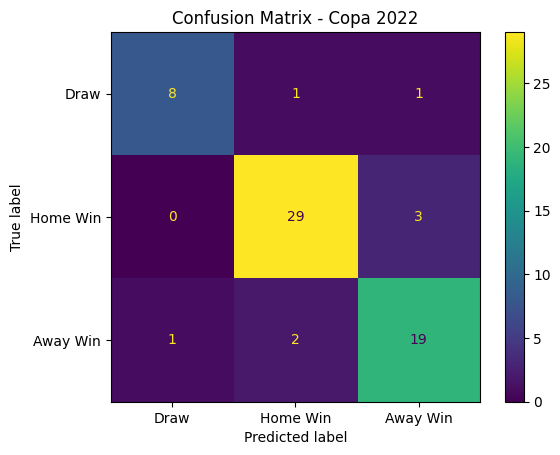

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2022, preds_2022)

labels = ["Draw", "Home Win", "Away Win"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()

plt.title("Confusion Matrix - Copa 2022")
plt.show()

#### Correlación de las variables
Vamos a calcular la correlación, muy usada para tener una idea sobre la elección de features para el modelo. La correlación mide literalmente cuál es el impacto de una variable en otra; en este caso, queremos saber qué variables tienen más impacto en nuestra variable objetivo.

In [37]:
!pip install matplotlib 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 66.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 105.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 99.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 50.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 30.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 53.2 MB/s eta 0:00:00


In [40]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.2 MB/s eta 0:00:00


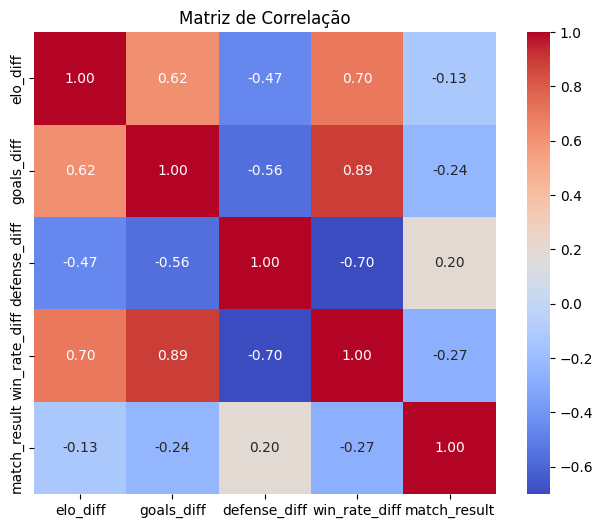

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "elo_diff",
    "goals_diff",
    "defense_diff",
    "win_rate_diff",
    "match_result"   # target
]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,       # mostra valores
    fmt=".2f",        # 2 casas decimais
    cmap="coolwarm",  
    square=True
)

plt.title("Matriz de Correlação")
plt.show()

#### Encapsulando el modelo para predicción
Crear variables globales y una función que recibe el equipo local y visitante y calcula los resultados de los partidos, así como la probabilidad de goles para cada equipo.

In [74]:
ratings_global = ratings
team_stats_global = team_stats
model_global = models["rf"]
home_goals_model_global = home_goals_model
away_goals_model_global = away_goals_model

In [76]:
import pandas as pd

def predict_match_simple(home_team, away_team):

    rating_home = ratings_global.get(home_team, 1500)
    rating_away = ratings_global.get(away_team, 1500)

    elo_diff = rating_home - rating_away

    teamA = team_stats_global.loc[home_team].to_dict() if home_team in team_stats_global.index else {
        "Goals_For": 1.2, "avg_goals_against": 1.2, "win_rate": 0.5
    }

    teamB = team_stats_global.loc[away_team].to_dict() if away_team in team_stats_global.index else {
        "Goals_For": 1.2, "avg_goals_against": 1.2, "win_rate": 0.5
    }

    features = pd.DataFrame([{
        "elo_diff": rating_home - rating_away,
        "goals_diff": teamA["Goals_For"] - teamB["Goals_For"],
        "defense_diff": teamA["avg_goals_against"] - teamB["avg_goals_against"],
        "win_rate_diff": teamA["win_rate"] - teamB["win_rate"]
    }])

    probs = model_global.predict_proba(features)[0]

    home_goals = home_goals_model_global.predict(features)[0]
    away_goals = away_goals_model_global.predict(features)[0]

    class_mapping = dict(zip(model_global.classes_, probs))

    return {
        "home_win": float(class_mapping.get(1, 0)),
        "draw": float(class_mapping.get(0, 0)),
        "away_win": float(class_mapping.get(2, 0)),
        "home_goals": float(home_goals),
        "away_goals": float(away_goals)
    }

#### Predecir el partido entre Brasil y Argentina
Ahora que tu función de predicción está lista, basta probar el modelo con los equipos y ver las probabilidades en acción.

In [82]:
result = predict_match_simple("Brazil", "Argentina")

print(f"Brazil win: {result['home_win']:.2%}")
print(f"Draw: {result['draw']:.2%}")
print(f"Argentina win: {result['away_win']:.2%}")
print(f"Score: {result['home_goals']:.1f} x {result['away_goals']:.1f}")

Brazil win: 73.00%
Draw: 17.00%
Argentina win: 10.00%
Score: 1.7 x 1.0


#### Desafíos:
- Haz la predicción de diferentes equipos que conozcas para ver si el modelo tiene sentido
- Agrega una nueva variable al modelo para verificar si mejora o empeora en la predicción de la copa
- Prueba un nuevo algoritmo de prueba usando la biblioteca de sklearn